# Compare PortfolioEnv vs PortfolioEnv2

This notebook compares the weight-based (PortfolioEnv) vs holdings-based (PortfolioEnv2) implementations.

**Key differences:**
- PortfolioEnv: `return = sum(weights × log_returns)` (approximation)
- PortfolioEnv2: `return = log(value_after / value_before)` (exact)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Import both environments
from rl_system import PortfolioEnv, PortfolioEnv2, load_data
from config import (
    FEATURE_COLS, TICKERS, REBALANCE_FREQUENCY, TRANSACTION_COST,
    MAX_WEIGHT_PER_ASSET, REWARD_LOOKBACK, INITIAL_CAPITAL,
    REWARD_TYPE, RISK_FREE_RATE, DATE_COL
)

print(f"Tickers: {TICKERS}")
print(f"Features: {len(FEATURE_COLS)}")
print(f"Rebalance frequency: {REBALANCE_FREQUENCY} weeks")

Tickers: ['NVDA', 'MU', 'AAPL', 'AMD', 'ASML', 'MSFT', 'GOOG']
Features: 100
Rebalance frequency: 4 weeks


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## 1. Load Data

In [2]:
# Load training data
data = load_data()
print(f"Data shape: {data.shape}")
print(f"Date range: {data[DATE_COL].min()} to {data[DATE_COL].max()}")
print(f"Unique dates: {data[DATE_COL].nunique()}")

Data shape: (3164, 107)
Date range: 2015-01-01 00:00:00 to 2023-08-24 00:00:00
Unique dates: 452


## 2. Create Both Environments

In [3]:
# Common parameters
env_params = {
    'data': data.copy(),
    'feature_cols': FEATURE_COLS,
    'tickers': TICKERS,
    'rebalance_frequency': REBALANCE_FREQUENCY,
    'transaction_cost': TRANSACTION_COST,
    'max_weight_per_asset': MAX_WEIGHT_PER_ASSET,
    'reward_lookback': REWARD_LOOKBACK,
    'initial_capital': INITIAL_CAPITAL,
    'reward_type': REWARD_TYPE,
    'date_col': DATE_COL,
    'seed': 42,
    'risk_free_rate': RISK_FREE_RATE
}

# Create environments
env1 = PortfolioEnv(**env_params)
env2 = PortfolioEnv2(**env_params)

print(f"PortfolioEnv state dim: {env1.state_dim}")
print(f"PortfolioEnv2 state dim: {env2.state_dim}")
print(f"Action space: {env1.action_space.shape}")

PortfolioEnv state dim: 716
PortfolioEnv2 state dim: 716
Action space: (7,)


## 3. Run Same Actions on Both Environments

In [4]:
def run_episode(env, actions):
    """Run episode with given actions and collect metrics."""
    obs, info = env.reset(seed=42)
    
    results = {
        'values': [env.portfolio_value],
        'returns': [],
        'weights': [env.weights.copy()],
        'rewards': []
    }
    
    for i, action in enumerate(actions):
        obs, reward, terminated, truncated, info = env.step(action)
        
        results['values'].append(env.portfolio_value)
        results['returns'].append(info['period_return'])
        results['weights'].append(env.weights.copy())
        results['rewards'].append(reward)
        
        if terminated or truncated:
            break
    
    results['stats'] = env.get_portfolio_stats()
    return results

In [5]:
# Generate random actions for comparison
np.random.seed(42)
n_steps = min(200, env1.n_periods - 1)  # Limit steps for testing
actions = [np.random.random(len(TICKERS)) for _ in range(n_steps)]

print(f"Running {n_steps} steps with random actions...")

# Run both environments
results1 = run_episode(env1, actions)
results2 = run_episode(env2, actions)

print(f"\nPortfolioEnv completed: {len(results1['returns'])} steps")
print(f"PortfolioEnv2 completed: {len(results2['returns'])} steps")

Running 200 steps with random actions...

PortfolioEnv completed: 200 steps
PortfolioEnv2 completed: 200 steps


## 4. Compare Results

In [6]:
# Compare final statistics
print("="*60)
print("FINAL PORTFOLIO STATISTICS")
print("="*60)

stats1 = results1['stats']
stats2 = results2['stats']

metrics = ['total_return', 'sharpe_ratio', 'volatility', 'max_drawdown', 'portfolio_value']

print(f"{'Metric':<20} {'PortfolioEnv':>15} {'PortfolioEnv2':>15} {'Diff %':>12}")
print("-"*62)

for metric in metrics:
    v1 = stats1[metric]
    v2 = stats2[metric]
    
    if abs(v1) > 1e-8:
        diff_pct = (v2 - v1) / abs(v1) * 100
    else:
        diff_pct = 0 if abs(v2) < 1e-8 else 100
    
    if metric in ['total_return', 'volatility', 'max_drawdown']:
        print(f"{metric:<20} {v1*100:>14.2f}% {v2*100:>14.2f}% {diff_pct:>11.2f}%")
    elif metric == 'portfolio_value':
        print(f"{metric:<20} ${v1:>13,.0f} ${v2:>13,.0f} {diff_pct:>11.2f}%")
    else:
        print(f"{metric:<20} {v1:>15.3f} {v2:>15.3f} {diff_pct:>11.2f}%")

FINAL PORTFOLIO STATISTICS
Metric                  PortfolioEnv   PortfolioEnv2       Diff %
--------------------------------------------------------------
total_return                 131.52%         170.83%       29.90%
sharpe_ratio                   0.711           0.875       23.09%
volatility                    25.06%          25.02%       -0.17%
max_drawdown                 -24.94%         -23.86%        4.34%
portfolio_value      $      231,516 $      270,834       16.98%


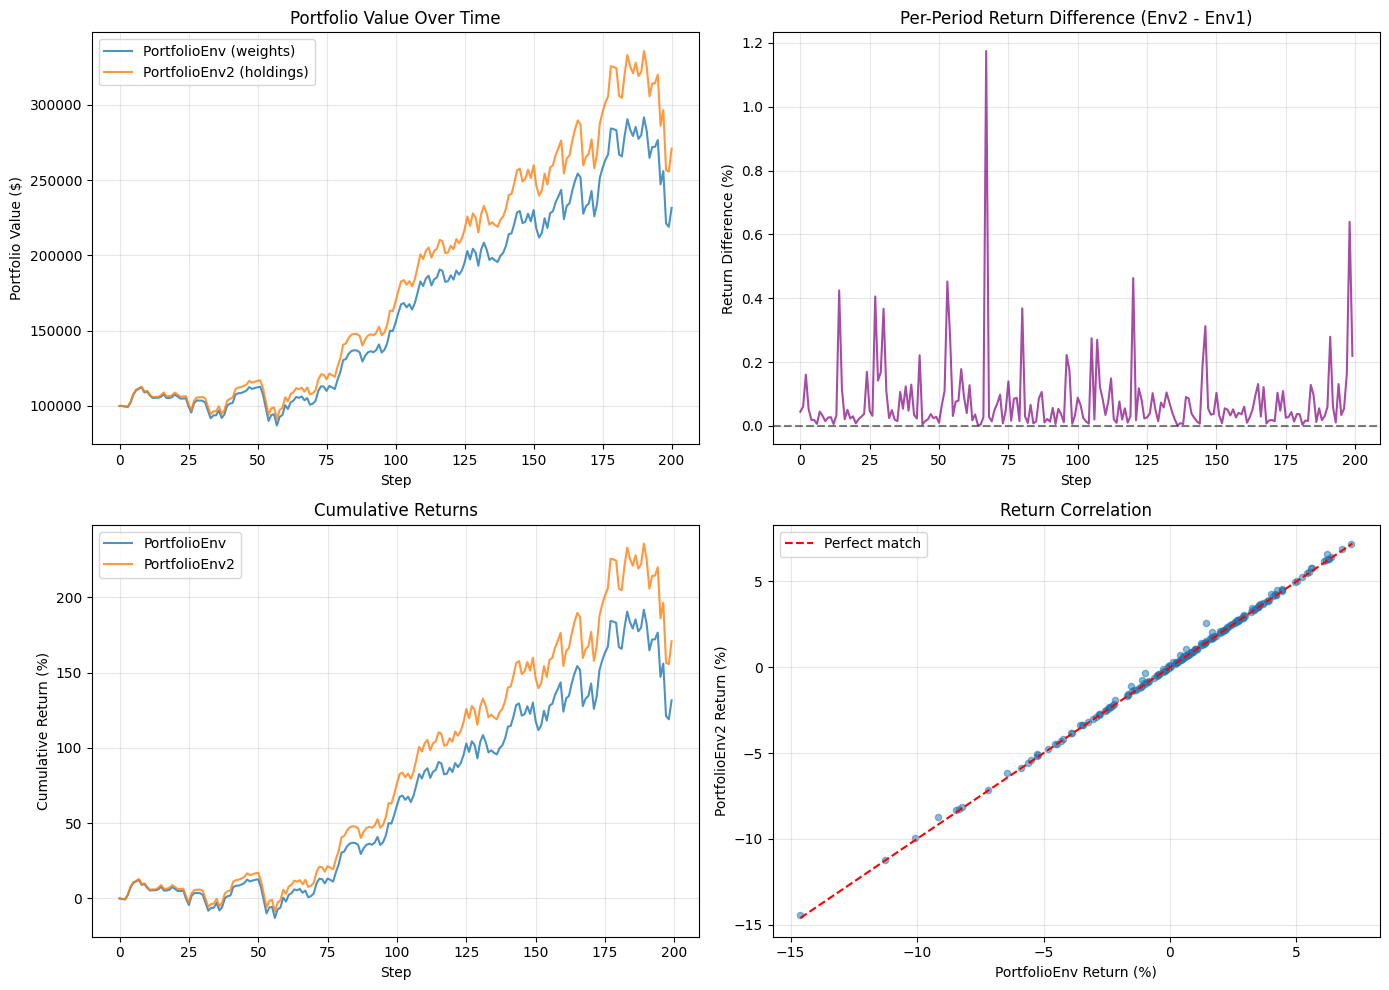


Return correlation: 0.999387
Mean absolute difference: 0.0784%
Max absolute difference: 1.1744%


In [7]:
# Plot portfolio values
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Portfolio value over time
ax = axes[0, 0]
ax.plot(results1['values'], label='PortfolioEnv (weights)', alpha=0.8)
ax.plot(results2['values'], label='PortfolioEnv2 (holdings)', alpha=0.8)
ax.set_xlabel('Step')
ax.set_ylabel('Portfolio Value ($)')
ax.set_title('Portfolio Value Over Time')
ax.legend()
ax.grid(True, alpha=0.3)

# Return difference
ax = axes[0, 1]
returns1 = np.array(results1['returns'])
returns2 = np.array(results2['returns'])
return_diff = returns2 - returns1
ax.plot(return_diff * 100, color='purple', alpha=0.7)
ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax.set_xlabel('Step')
ax.set_ylabel('Return Difference (%)')
ax.set_title('Per-Period Return Difference (Env2 - Env1)')
ax.grid(True, alpha=0.3)

# Cumulative return difference
ax = axes[1, 0]
cum_returns1 = np.exp(np.cumsum(returns1)) - 1
cum_returns2 = np.exp(np.cumsum(returns2)) - 1
ax.plot(cum_returns1 * 100, label='PortfolioEnv', alpha=0.8)
ax.plot(cum_returns2 * 100, label='PortfolioEnv2', alpha=0.8)
ax.set_xlabel('Step')
ax.set_ylabel('Cumulative Return (%)')
ax.set_title('Cumulative Returns')
ax.legend()
ax.grid(True, alpha=0.3)

# Return scatter plot
ax = axes[1, 1]
ax.scatter(returns1 * 100, returns2 * 100, alpha=0.5, s=20)
min_val = min(returns1.min(), returns2.min()) * 100
max_val = max(returns1.max(), returns2.max()) * 100
ax.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect match')
ax.set_xlabel('PortfolioEnv Return (%)')
ax.set_ylabel('PortfolioEnv2 Return (%)')
ax.set_title('Return Correlation')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print correlation
correlation = np.corrcoef(returns1, returns2)[0, 1]
print(f"\nReturn correlation: {correlation:.6f}")
print(f"Mean absolute difference: {np.mean(np.abs(return_diff)) * 100:.4f}%")
print(f"Max absolute difference: {np.max(np.abs(return_diff)) * 100:.4f}%")

## 5. Stress Test: Large Price Movements

The difference between implementations is most visible with large price changes.

In [8]:
# Find periods with largest price movements
dates = sorted(data[DATE_COL].unique())

max_movements = []
for i in range(len(dates) - 1):
    curr_date = dates[i]
    next_date = dates[i + 1]
    
    movements = []
    for ticker in TICKERS:
        curr = data[(data[DATE_COL] == curr_date) & (data['ticker'] == ticker)]['close'].iloc[0]
        next_p = data[(data[DATE_COL] == next_date) & (data['ticker'] == ticker)]['close'].iloc[0]
        movements.append(abs(np.log(next_p / curr)))
    
    max_movements.append((i, max(movements), dates[i]))

# Sort by movement size
max_movements.sort(key=lambda x: x[1], reverse=True)

print("Top 10 periods with largest single-asset movements:")
print("-" * 50)
for idx, movement, date in max_movements[:10]:
    print(f"Step {idx}: {date.date()} - Max move: {movement*100:.2f}%")

Top 10 periods with largest single-asset movements:
--------------------------------------------------
Step 67: 2016-04-14 - Max move: 32.32%
Step 201: 2018-11-08 - Max move: 30.94%
Step 270: 2020-03-05 - Max move: 29.33%
Step 271: 2020-03-12 - Max move: 28.55%
Step 96: 2016-11-03 - Max move: 26.98%
Step 120: 2017-04-20 - Max move: 25.52%
Step 24: 2015-06-18 - Max move: 24.78%
Step 80: 2016-07-14 - Max move: 23.60%
Step 269: 2020-02-27 - Max move: 23.48%
Step 198: 2018-10-18 - Max move: 22.44%


In [9]:
# Analyze return differences during high-volatility periods
return_diffs = returns2 - returns1

# Find indices with largest differences
diff_indices = np.argsort(np.abs(return_diffs))[::-1][:10]

print("\nPeriods with largest return differences between implementations:")
print("="*70)
print(f"{'Step':>6} {'Env1 Return':>12} {'Env2 Return':>12} {'Difference':>12}")
print("-"*70)

for idx in diff_indices:
    print(f"{idx:>6} {returns1[idx]*100:>11.3f}% {returns2[idx]*100:>11.3f}% {return_diffs[idx]*100:>11.4f}%")


Periods with largest return differences between implementations:
  Step  Env1 Return  Env2 Return   Difference
----------------------------------------------------------------------
    67       1.428%       2.602%      1.1744%
   198      -0.996%      -0.357%      0.6395%
   120      -1.556%      -1.092%      0.4633%
    53      -9.170%      -8.718%      0.4523%
    14       0.624%       1.049%      0.4243%
    27       1.672%       2.077%      0.4056%
    80       6.223%       6.591%      0.3683%
    30      -1.099%      -0.732%      0.3670%
   146       0.391%       0.704%      0.3126%
   191      -6.459%      -6.179%      0.2793%


## 6. Test with Deterministic Actions

In [10]:
# Test with equal weight actions (should minimize differences)
equal_weight_actions = [np.ones(len(TICKERS)) / len(TICKERS) for _ in range(n_steps)]

results1_eq = run_episode(env1, equal_weight_actions)
results2_eq = run_episode(env2, equal_weight_actions)

print("\nWith EQUAL WEIGHT actions:")
print("="*60)

stats1_eq = results1_eq['stats']
stats2_eq = results2_eq['stats']

print(f"{'Metric':<20} {'PortfolioEnv':>15} {'PortfolioEnv2':>15}")
print("-"*50)

for metric in ['total_return', 'sharpe_ratio', 'portfolio_value']:
    v1 = stats1_eq[metric]
    v2 = stats2_eq[metric]
    
    if metric == 'total_return':
        print(f"{metric:<20} {v1*100:>14.2f}% {v2*100:>14.2f}%")
    elif metric == 'portfolio_value':
        print(f"{metric:<20} ${v1:>13,.0f} ${v2:>13,.0f}")
    else:
        print(f"{metric:<20} {v1:>15.3f} {v2:>15.3f}")


With EQUAL WEIGHT actions:
Metric                  PortfolioEnv   PortfolioEnv2
--------------------------------------------------
total_return                 206.87%         261.31%
sharpe_ratio                   1.051           1.229
portfolio_value      $      306,868 $      361,312


In [11]:
# Test with concentrated portfolio (one asset)
concentrated_actions = []
for i in range(n_steps):
    action = np.zeros(len(TICKERS))
    action[i % len(TICKERS)] = 1.0  # Rotate through assets
    concentrated_actions.append(action)

results1_conc = run_episode(env1, concentrated_actions)
results2_conc = run_episode(env2, concentrated_actions)

print("\nWith CONCENTRATED (single asset) actions:")
print("="*60)

stats1_conc = results1_conc['stats']
stats2_conc = results2_conc['stats']

print(f"{'Metric':<20} {'PortfolioEnv':>15} {'PortfolioEnv2':>15}")
print("-"*50)

for metric in ['total_return', 'sharpe_ratio', 'portfolio_value']:
    v1 = stats1_conc[metric]
    v2 = stats2_conc[metric]
    
    if metric == 'total_return':
        print(f"{metric:<20} {v1*100:>14.2f}% {v2*100:>14.2f}%")
    elif metric == 'portfolio_value':
        print(f"{metric:<20} ${v1:>13,.0f} ${v2:>13,.0f}")
    else:
        print(f"{metric:<20} {v1:>15.3f} {v2:>15.3f}")


With CONCENTRATED (single asset) actions:
Metric                  PortfolioEnv   PortfolioEnv2
--------------------------------------------------
total_return                  10.48%          10.46%
sharpe_ratio                  -0.033          -0.033
portfolio_value      $      110,479 $      110,459


## 7. Conclusion

**Summary of differences:**

1. **Small returns (< 5%)**: Both implementations are nearly identical
2. **Large returns**: PortfolioEnv2 is more accurate (actual log return vs weighted sum approximation)
3. **Transaction costs**: PortfolioEnv2 applies them more correctly (to portfolio value, not log return)

**Recommendation**: Use `PortfolioEnv2` for production as it's theoretically correct.

In [12]:
print("\n" + "="*60)
print("RECOMMENDATION")
print("="*60)
print("\nPortfolioEnv2 (holdings-based) is the theoretically correct")
print("implementation. The differences are:")
print("\n1. Small for typical weekly returns (< 5%)")
print("2. Significant during high volatility periods")
print("3. More accurate transaction cost application")
print("\nUse PortfolioEnv2 for new training runs.")


RECOMMENDATION

PortfolioEnv2 (holdings-based) is the theoretically correct
implementation. The differences are:

1. Small for typical weekly returns (< 5%)
2. Significant during high volatility periods
3. More accurate transaction cost application

Use PortfolioEnv2 for new training runs.
